## AUDITORÍA SUMAPAZ + AGREGACIÓN ESPACIAL + MORBILIDAD POR LOCALIDAD

In [3]:
# ============================================================
# CELDA ÚNICA: BUSCAR ARCHIVOS DE RESULTADOS SANITARIOS/ECONÓMICOS
# Excluye .venv y muestra candidatos reales para reemplazar resultados_path
# ============================================================

import pandas as pd
from pathlib import Path
import unicodedata

BASE = Path(r"D:\TRABAJO DE GRADO BEN-MAP")

# ------------------------------------------------------------
# 1. FUNCIÓN PARA NORMALIZAR TEXTO
# ------------------------------------------------------------
def normalizar(x):
    x = str(x).lower()
    x = "".join(
        c for c in unicodedata.normalize("NFD", x)
        if unicodedata.category(c) != "Mn"
    )
    return x

# ------------------------------------------------------------
# 2. CARPETAS A IGNORAR
# ------------------------------------------------------------
ignorar = {
    ".venv", "venv", "__pycache__", ".git",
    "site-packages", "lib", "include", "scripts"
}

def ruta_valida(path):
    partes = {normalizar(p) for p in path.parts}
    return len(partes.intersection(ignorar)) == 0

# ------------------------------------------------------------
# 3. BUSCAR ARCHIVOS TABULARES
# ------------------------------------------------------------
extensiones = ["*.csv", "*.xlsx", "*.xls", "*.parquet"]
archivos = []

for ext in extensiones:
    archivos.extend([p for p in BASE.rglob(ext) if ruta_valida(p)])

print(f"Archivos tabulares encontrados fuera de .venv: {len(archivos)}")

# ------------------------------------------------------------
# 4. PALABRAS CLAVE PARA IDENTIFICAR RESULTADOS
# ------------------------------------------------------------
palabras_nombre = [
    "resultado", "resultados", "salud", "sanitario", "sanitaria",
    "econom", "valor", "valoracion", "benmap", "casos",
    "endpoint", "impacto", "incidencia", "morbilidad",
    "localidad", "celda", "sensibilidad", "corrida"
]

palabras_columnas_fuertes = [
    "cell", "celda", "cell_id", "grid", "grid_id",
    "localidad", "locnombre", "loc",
    "endpoint", "health", "evento", "desenlace",
    "pollutant", "contaminante",
    "cases", "casos", "incidence", "incidencia",
    "value", "valor", "cop", "usd", "economic", "economico"
]

# ------------------------------------------------------------
# 5. LEER ENCABEZADOS Y RANKEAR CANDIDATOS
# ------------------------------------------------------------
candidatos = []

for path in archivos:
    nombre_norm = normalizar(path.name)
    ruta_norm = normalizar(path)
    
    score_nombre = sum(p in nombre_norm or p in ruta_norm for p in palabras_nombre)
    
    columnas = []
    nfilas_muestra = None
    error = None
    
    try:
        if path.suffix.lower() == ".csv":
            try:
                df_head = pd.read_csv(path, encoding="utf-8-sig", nrows=5)
            except UnicodeDecodeError:
                df_head = pd.read_csv(path, encoding="latin1", nrows=5)
            columnas = df_head.columns.tolist()
            nfilas_muestra = len(df_head)
            
        elif path.suffix.lower() in [".xlsx", ".xls"]:
            xls = pd.ExcelFile(path)
            hoja = xls.sheet_names[0]
            df_head = pd.read_excel(path, sheet_name=hoja, nrows=5)
            columnas = df_head.columns.tolist()
            nfilas_muestra = len(df_head)
            
        elif path.suffix.lower() == ".parquet":
            df_head = pd.read_parquet(path)
            columnas = df_head.columns.tolist()
            nfilas_muestra = min(len(df_head), 5)
            
    except Exception as e:
        error = str(e)
    
    columnas_norm = [normalizar(c) for c in columnas]
    score_cols = 0
    
    for palabra in palabras_columnas_fuertes:
        if any(palabra in c for c in columnas_norm):
            score_cols += 1
    
    score_total = score_nombre + (2 * score_cols)
    
    if score_total > 0:
        candidatos.append({
            "score": score_total,
            "score_nombre": score_nombre,
            "score_columnas": score_cols,
            "archivo": str(path),
            "nombre": path.name,
            "columnas": columnas,
            "error": error
        })

candidatos = sorted(candidatos, key=lambda x: x["score"], reverse=True)

# ------------------------------------------------------------
# 6. MOSTRAR LOS MEJORES CANDIDATOS
# ------------------------------------------------------------
print("\n==============================")
print("TOP CANDIDATOS DE RESULTADOS")
print("==============================")

if len(candidatos) == 0:
    print("No se encontraron candidatos claros.")
    print("Archivos encontrados fuera de .venv:")
    for p in archivos[:50]:
        print(" -", p)
else:
    for i, c in enumerate(candidatos[:30], start=1):
        print(f"\n[{i}] SCORE={c['score']} | columnas={c['score_columnas']} | nombre={c['score_nombre']}")
        print("Archivo:", c["archivo"])
        print("Columnas:", c["columnas"][:30])
        if c["error"]:
            print("Error lectura:", c["error"])

# ------------------------------------------------------------
# 7. PROPONER AUTOMÁTICAMENTE EL MEJOR ARCHIVO
# ------------------------------------------------------------
if len(candidatos) > 0:
    mejor = candidatos[0]
    print("\n==============================")
    print("ARCHIVO MÁS PROBABLE")
    print("==============================")
    print(mejor["archivo"])
    print("\nPara usarlo en la siguiente celda, copia esto:")
    print(f'resultados_path = Path(r"{mejor["archivo"]}")')
else:
    print("\nNo se pudo proponer archivo automático.")

Archivos tabulares encontrados fuera de .venv: 1002

TOP CANDIDATOS DE RESULTADOS

[1] SCORE=29 | columnas=11 | nombre=7
Archivo: D:\TRABAJO DE GRADO BEN-MAP\RESULTADOS_FINALES\01_insumos_resultados\benmap_base\valoracion_economica_por_celda_cop.csv
Columnas: ['run_id', 'pollutant', 'endpoint_group', 'endpoint', 'start_age', 'end_age', 'cell_id', 'Row', 'Column', 'concentration_baseline', 'concentration_control', 'delta_concentration', 'population_target', 'incidence_target', 'beta', 'beta_se', 'economic_method', 'valuation_parameter_name', 'valuation_value_fixed', 'rr', 'af_avoided', 'baseline_cases', 'avoided_cases', 'valuation_value_used_usd_2015', 'economic_value_usd_2015', 'fx_cop_per_usd_2015', 'ipc_factor_2015_to_local_base', 'valuation_value_used_cop_2015', 'economic_value_cop_2015', 'economic_value_cop_local_base']

[2] SCORE=29 | columnas=11 | nombre=7
Archivo: D:\TRABAJO DE GRADO BEN-MAP\RESULTADOS_FINALES\06_trazabilidad_archivos\05_benmap_base\valoracion_economica_por_celd

Archivos cargados:
Grid: (254, 4)
Localidades: (20, 7)
Población: (5, 7)
Resultados: (1016, 30)

Columnas resultados:
['run_id', 'pollutant', 'endpoint_group', 'endpoint', 'start_age', 'end_age', 'cell_id', 'Row', 'Column', 'concentration_baseline', 'concentration_control', 'delta_concentration', 'population_target', 'incidence_target', 'beta', 'beta_se', 'economic_method', 'valuation_parameter_name', 'valuation_value_fixed', 'rr', 'af_avoided', 'baseline_cases', 'avoided_cases', 'valuation_value_used_usd_2015', 'economic_value_usd_2015', 'fx_cop_per_usd_2015', 'ipc_factor_2015_to_local_base', 'valuation_value_used_cop_2015', 'economic_value_cop_2015', 'economic_value_cop_local_base']

Columnas detectadas:
grid_id_col: cell_id
res_id_col: cell_id
loc_name_col: LocNombre
pollutant_col: pollutant
endpoint_col: endpoint
cases_col: avoided_cases
value_col: economic_value_cop_2015

Control de pesos por celda:
count    2.540000e+02
mean     1.000000e+00
std      8.435498e-12
min      1.00000

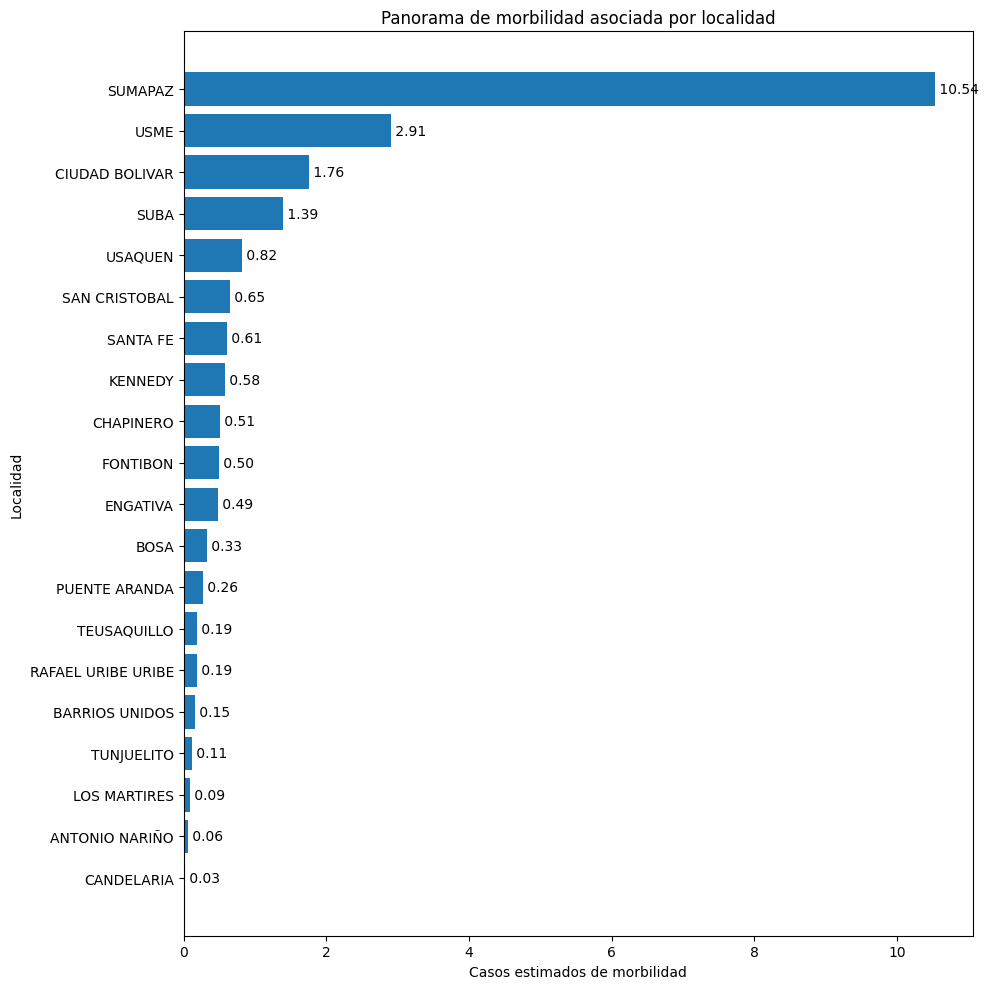


TOP 10 POR VALOR ECONÓMICO TOTAL
         LocNombre  poblacion_total  casos_totales  valor_total_cop  \
15         SUMAPAZ     3.065065e+07      12.199967     4.041523e+10   
19            USME     8.440601e+06       3.364456     1.114159e+10   
5   CIUDAD BOLIVAR     5.102083e+06       2.042678     6.889204e+09   
14            SUBA     3.946578e+06       1.596389     5.100682e+09   
18         USAQUEN     2.558906e+06       0.966957     3.503405e+09   
12   SAN CRISTOBAL     1.926903e+06       0.751916     2.514810e+09   
13        SANTA FE     1.772767e+06       0.705319     2.345012e+09   
8          KENNEDY     1.514486e+06       0.667739     2.192631e+09   
4        CHAPINERO     1.491707e+06       0.593683     2.021800e+09   
6         ENGATIVA     1.408184e+06       0.564091     1.911374e+09   

    part_valor_pct  casos_x_100k  valor_percapita_cop  
15       47.321946      0.039803          1318.576532  
19       13.045620      0.039860          1319.999530  
5         8.0665

In [4]:
# ============================================================
# CELDA ÚNICA: AUDITORÍA SUMAPAZ + AGREGACIÓN ESPACIAL + MORBILIDAD POR LOCALIDAD
# ============================================================

import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
import unicodedata
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. RUTAS
# ------------------------------------------------------------
BASE = Path(r"D:\TRABAJO DE GRADO BEN-MAP")

grid_path = BASE / "SALIDAS_BENMAP" / "benmap_grid_definition_WGS1984.shp"

localidades_path = Path(
    r"D:\TRABAJO DE GRADO BEN-MAP\RESULTADOS_FINALES\06_trazabilidad_archivos\01_entradas\bogota\Loca.shp"
)

poblacion_path = BASE / "SALIDAS_BENMAP" / "population_bogota_rangos_2026.csv"

resultados_path = Path(
    r"D:\TRABAJO DE GRADO BEN-MAP\RESULTADOS_FINALES\01_insumos_resultados\benmap_base\valoracion_economica_por_celda_cop.csv"
)

out_dir = BASE / "RESULTADOS_FINALES" / "03_revision_sumapaz_morbilidad"
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. FUNCIONES AUXILIARES
# ------------------------------------------------------------
def normalizar(x):
    x = str(x).lower().strip()
    x = "".join(
        c for c in unicodedata.normalize("NFD", x)
        if unicodedata.category(c) != "Mn"
    )
    return x

def detectar_columna(cols, patrones, obligatoria=True, nombre="columna"):
    cols_norm = {normalizar(c): c for c in cols}
    
    for p in patrones:
        p_norm = normalizar(p)
        for c_norm, c_original in cols_norm.items():
            if c_norm == p_norm:
                return c_original
    
    for p in patrones:
        p_norm = normalizar(p)
        for c_norm, c_original in cols_norm.items():
            if p_norm in c_norm:
                return c_original
    
    if obligatoria:
        raise ValueError(f"No pude detectar {nombre}. Columnas disponibles: {list(cols)}")
    return None

def leer_csv_robusto(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin1")

# ------------------------------------------------------------
# 3. CARGAR ARCHIVOS
# ------------------------------------------------------------
grid = gpd.read_file(grid_path)
locs = gpd.read_file(localidades_path)
pob = leer_csv_robusto(poblacion_path)
res = leer_csv_robusto(resultados_path)

print("Archivos cargados:")
print("Grid:", grid.shape)
print("Localidades:", locs.shape)
print("Población:", pob.shape)
print("Resultados:", res.shape)

print("\nColumnas resultados:")
print(res.columns.tolist())

# ------------------------------------------------------------
# 4. DETECTAR COLUMNAS
# ------------------------------------------------------------
grid_id_col = detectar_columna(
    grid.columns,
    ["cell_id", "cellid", "grid_id", "id", "ID", "FID", "OBJECTID"],
    obligatoria=False,
    nombre="ID de celda en grid"
)

res_id_col = detectar_columna(
    res.columns,
    ["cell_id", "cellid", "grid_id", "id_celda", "celda"],
    obligatoria=True,
    nombre="ID de celda en resultados"
)

loc_name_col = detectar_columna(
    locs.columns,
    ["LocNombre", "LOCALIDAD", "localidad", "NOMBRE", "Nombre", "NOMBRE_LOC", "locnombre", "LocName"],
    obligatoria=False,
    nombre="nombre de localidad"
)

if loc_name_col is None:
    posibles = [c for c in locs.columns if ("loc" in normalizar(c)) or ("nom" in normalizar(c))]
    if len(posibles) > 0:
        loc_name_col = posibles[0]
    else:
        raise ValueError(f"No pude detectar columna de localidad. Columnas: {locs.columns.tolist()}")

pollutant_col = detectar_columna(
    res.columns,
    ["pollutant", "contaminante"],
    obligatoria=False,
    nombre="contaminante"
)

endpoint_col = detectar_columna(
    res.columns,
    ["endpoint", "desenlace", "health_endpoint"],
    obligatoria=False,
    nombre="endpoint"
)

cases_col = detectar_columna(
    res.columns,
    ["avoided_cases", "cases", "casos", "incidence", "incidence_change", "delta_y", "health_impact"],
    obligatoria=False,
    nombre="casos evitados"
)

value_col = detectar_columna(
    res.columns,
    ["valuation_value_cop", "value_cop", "valor_total_cop", "valor_cop", "valuation_value", "economic_value", "valor"],
    obligatoria=False,
    nombre="valor económico"
)

print("\nColumnas detectadas:")
print("grid_id_col:", grid_id_col)
print("res_id_col:", res_id_col)
print("loc_name_col:", loc_name_col)
print("pollutant_col:", pollutant_col)
print("endpoint_col:", endpoint_col)
print("cases_col:", cases_col)
print("value_col:", value_col)

if cases_col is None:
    raise ValueError("No encontré columna de casos evitados. Revisa columnas del archivo de resultados.")

if value_col is None:
    raise ValueError("No encontré columna de valor económico. Revisa columnas del archivo de resultados.")

# ------------------------------------------------------------
# 5. ASEGURAR ID DE CELDA EN GRID
# ------------------------------------------------------------
grid = grid.copy()

if grid_id_col is None:
    # Si el grid no tiene cell_id, intentamos construirlo con Row/Column si existen
    row_grid = detectar_columna(grid.columns, ["Row", "row", "fila"], obligatoria=False, nombre="Row grid")
    col_grid = detectar_columna(grid.columns, ["Column", "Col", "column", "columna"], obligatoria=False, nombre="Column grid")
    
    if row_grid is not None and col_grid is not None:
        grid["cell_id_auto"] = grid[row_grid].astype(str) + "_" + grid[col_grid].astype(str)
        grid_id_col = "cell_id_auto"
    else:
        grid["cell_id_auto"] = np.arange(len(grid))
        grid_id_col = "cell_id_auto"
        print("\nAdvertencia: el grid no tenía ID claro. Se creó un ID por índice.")

# Convertir IDs a texto para evitar problemas de tipo
grid[grid_id_col] = grid[grid_id_col].astype(str)
res[res_id_col] = res[res_id_col].astype(str)

# ------------------------------------------------------------
# 6. CRS Y ÁREAS
# ------------------------------------------------------------
if grid.crs is None:
    print("\nAdvertencia: el grid no tenía CRS. Se asigna EPSG:4326 por el nombre WGS1984.")
    grid = grid.set_crs("EPSG:4326")

if locs.crs is None:
    print("\nAdvertencia: localidades no tenía CRS. Se asigna EPSG:4326. Verifica si corresponde.")
    locs = locs.set_crs("EPSG:4326")

locs = locs.to_crs(grid.crs)

# Proyección para área en metros
TARGET_CRS = "EPSG:3116"
grid_m = grid.to_crs(TARGET_CRS)
locs_m = locs.to_crs(TARGET_CRS)

grid_m = grid_m[[grid_id_col, "geometry"]].copy()
locs_m = locs_m[[loc_name_col, "geometry"]].copy()

grid_m["area_celda_m2"] = grid_m.geometry.area

# ------------------------------------------------------------
# 7. INTERSECCIÓN GRID x LOCALIDAD
# ------------------------------------------------------------
inter = gpd.overlay(
    grid_m,
    locs_m,
    how="intersection",
    keep_geom_type=False
)

inter["area_inter_m2"] = inter.geometry.area
inter["peso_area"] = inter["area_inter_m2"] / inter["area_celda_m2"]

# Control: pesos por celda
check_pesos = (
    inter.groupby(grid_id_col)["peso_area"]
    .sum()
    .reset_index(name="suma_pesos")
)

check_pesos.to_csv(out_dir / "control_pesos_area_por_celda.csv", index=False, encoding="utf-8-sig")

print("\nControl de pesos por celda:")
print(check_pesos["suma_pesos"].describe())

# ------------------------------------------------------------
# 8. PREPARAR POBLACIÓN POR CELDA
# ------------------------------------------------------------
pob_id_col = detectar_columna(
    pob.columns,
    ["cell_id", "cellid", "grid_id", "id_celda", "celda"],
    obligatoria=False,
    nombre="ID de celda en población"
)

if pob_id_col is not None:
    pob[pob_id_col] = pob[pob_id_col].astype(str)
    
    pop_col = detectar_columna(
        pob.columns,
        ["population", "poblacion", "pop", "pob", "population_target"],
        obligatoria=False,
        nombre="población"
    )
    
    if pop_col is None:
        numeric_cols = pob.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [c for c in numeric_cols if normalizar(c) not in ["year", "ano", "año", "row", "column"]]
        if len(numeric_cols) == 0:
            raise ValueError("No encontré columna numérica de población.")
        pop_col = numeric_cols[0]
        print(f"\nAdvertencia: se usó como población la columna numérica: {pop_col}")
    
    pob_cell = (
        pob.groupby(pob_id_col, as_index=False)[pop_col]
        .sum()
        .rename(columns={pob_id_col: grid_id_col, pop_col: "poblacion_celda"})
    )
else:
    # Si no hay población por celda, usar población del archivo de resultados si existe
    pop_res_col = detectar_columna(
        res.columns,
        ["population_target", "population", "poblacion", "pop"],
        obligatoria=False,
        nombre="población en resultados"
    )
    
    if pop_res_col is None:
        print("\nAdvertencia: no se encontró población por celda. Se calcularán tasas como NaN.")
        pob_cell = pd.DataFrame({grid_id_col: grid_m[grid_id_col].unique(), "poblacion_celda": np.nan})
    else:
        pob_cell = (
            res.groupby(res_id_col, as_index=False)[pop_res_col]
            .max()
            .rename(columns={res_id_col: grid_id_col, pop_res_col: "poblacion_celda"})
        )

# Agregar población a intersección
inter = inter.merge(pob_cell, on=grid_id_col, how="left")
inter["poblacion_asignada"] = inter["poblacion_celda"] * inter["peso_area"]

# ------------------------------------------------------------
# 9. MERGE RESULTADOS CON INTERSECCIÓN
# ------------------------------------------------------------
cols_res = [res_id_col, cases_col, value_col]

if pollutant_col is not None:
    cols_res.append(pollutant_col)

if endpoint_col is not None:
    cols_res.append(endpoint_col)

endpoint_group_col = detectar_columna(
    res.columns,
    ["endpoint_group", "grupo_endpoint", "grupo"],
    obligatoria=False,
    nombre="grupo endpoint"
)

if endpoint_group_col is not None:
    cols_res.append(endpoint_group_col)

res_small = res[cols_res].copy()

# Asegurar numéricos
res_small[cases_col] = pd.to_numeric(res_small[cases_col], errors="coerce").fillna(0)
res_small[value_col] = pd.to_numeric(res_small[value_col], errors="coerce").fillna(0)

inter_res = inter.merge(
    res_small,
    left_on=grid_id_col,
    right_on=res_id_col,
    how="left"
)

inter_res[cases_col] = inter_res[cases_col].fillna(0)
inter_res[value_col] = inter_res[value_col].fillna(0)

inter_res["casos_asignados"] = inter_res[cases_col] * inter_res["peso_area"]
inter_res["valor_asignado_cop"] = inter_res[value_col] * inter_res["peso_area"]

# ------------------------------------------------------------
# 10. RESUMEN POR LOCALIDAD
# ------------------------------------------------------------
resumen_loc = (
    inter_res.groupby(loc_name_col, dropna=False)
    .agg(
        area_m2=("area_inter_m2", "sum"),
        n_celdas=(grid_id_col, "nunique"),
        poblacion_total=("poblacion_asignada", "sum"),
        casos_totales=("casos_asignados", "sum"),
        valor_total_cop=("valor_asignado_cop", "sum")
    )
    .reset_index()
)

total_casos = resumen_loc["casos_totales"].sum()
total_valor = resumen_loc["valor_total_cop"].sum()

resumen_loc["part_casos_pct"] = np.where(total_casos > 0, 100 * resumen_loc["casos_totales"] / total_casos, np.nan)
resumen_loc["part_valor_pct"] = np.where(total_valor > 0, 100 * resumen_loc["valor_total_cop"] / total_valor, np.nan)

resumen_loc["casos_x_100k"] = np.where(
    resumen_loc["poblacion_total"] > 0,
    100000 * resumen_loc["casos_totales"] / resumen_loc["poblacion_total"],
    np.nan
)

resumen_loc["valor_percapita_cop"] = np.where(
    resumen_loc["poblacion_total"] > 0,
    resumen_loc["valor_total_cop"] / resumen_loc["poblacion_total"],
    np.nan
)

resumen_loc["area_km2"] = resumen_loc["area_m2"] / 1e6
resumen_loc["densidad_pob_km2"] = np.where(
    resumen_loc["area_km2"] > 0,
    resumen_loc["poblacion_total"] / resumen_loc["area_km2"],
    np.nan
)

resumen_loc = resumen_loc.sort_values("valor_total_cop", ascending=False)
resumen_loc.to_csv(out_dir / "auditoria_agregacion_por_localidad.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------
# 11. RESUMEN DETALLADO POR LOCALIDAD, CONTAMINANTE Y ENDPOINT
# ------------------------------------------------------------
group_cols = [loc_name_col]

if pollutant_col is not None:
    group_cols.append(pollutant_col)

if endpoint_group_col is not None:
    group_cols.append(endpoint_group_col)

if endpoint_col is not None:
    group_cols.append(endpoint_col)

resumen_det = (
    inter_res.groupby(group_cols, dropna=False)
    .agg(
        poblacion_total=("poblacion_asignada", "sum"),
        casos_totales=("casos_asignados", "sum"),
        valor_total_cop=("valor_asignado_cop", "sum")
    )
    .reset_index()
)

resumen_det["casos_x_100k"] = np.where(
    resumen_det["poblacion_total"] > 0,
    100000 * resumen_det["casos_totales"] / resumen_det["poblacion_total"],
    np.nan
)

resumen_det["valor_percapita_cop"] = np.where(
    resumen_det["poblacion_total"] > 0,
    resumen_det["valor_total_cop"] / resumen_det["poblacion_total"],
    np.nan
)

resumen_det.to_csv(out_dir / "detalle_localidad_contaminante_endpoint.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------
# 12. PANORAMA SOLO MORBILIDAD POR LOCALIDAD
# ------------------------------------------------------------
df_morb = resumen_det.copy()

if endpoint_col is not None:
    patrones_mortalidad = "mortal|mortality|death|muert|fallec"
    df_morb = df_morb[
        ~df_morb[endpoint_col].astype(str).str.lower().str.contains(patrones_mortalidad, na=False)
    ]

morbilidad_loc = (
    df_morb.groupby(loc_name_col, dropna=False)
    .agg(
        poblacion_total=("poblacion_total", "sum"),
        casos_morbilidad=("casos_totales", "sum"),
        valor_morbilidad_cop=("valor_total_cop", "sum")
    )
    .reset_index()
)

morbilidad_loc["morbilidad_x_100k"] = np.where(
    morbilidad_loc["poblacion_total"] > 0,
    100000 * morbilidad_loc["casos_morbilidad"] / morbilidad_loc["poblacion_total"],
    np.nan
)

morbilidad_loc = morbilidad_loc.sort_values("casos_morbilidad", ascending=False)
morbilidad_loc.to_csv(out_dir / "panorama_morbilidad_por_localidad.csv", index=False, encoding="utf-8-sig")

# Gráfico de barras horizontal
plot_df = morbilidad_loc.sort_values("casos_morbilidad", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_df[loc_name_col], plot_df["casos_morbilidad"])
plt.xlabel("Casos estimados de morbilidad")
plt.ylabel("Localidad")
plt.title("Panorama de morbilidad asociada por localidad")

for i, v in enumerate(plot_df["casos_morbilidad"]):
    if pd.notnull(v):
        plt.text(v, i, f" {v:,.2f}", va="center")

plt.tight_layout()
plt.savefig(out_dir / "panorama_morbilidad_por_localidad.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 13. REVISIÓN ESPECIAL DE SUMAPAZ
# ------------------------------------------------------------
resumen_loc["_loc_norm"] = resumen_loc[loc_name_col].apply(normalizar)
sumapaz = resumen_loc[resumen_loc["_loc_norm"].str.contains("sumapaz", na=False)].copy()

ranking_valor = resumen_loc.sort_values("valor_total_cop", ascending=False).copy()
ranking_casos = resumen_loc.sort_values("casos_totales", ascending=False).copy()
ranking_tasa = resumen_loc.sort_values("casos_x_100k", ascending=False).copy()
ranking_percapita = resumen_loc.sort_values("valor_percapita_cop", ascending=False).copy()

ranking_valor.to_csv(out_dir / "ranking_valor_total.csv", index=False, encoding="utf-8-sig")
ranking_casos.to_csv(out_dir / "ranking_casos_totales.csv", index=False, encoding="utf-8-sig")
ranking_tasa.to_csv(out_dir / "ranking_tasa_casos_100k.csv", index=False, encoding="utf-8-sig")
ranking_percapita.to_csv(out_dir / "ranking_valor_percapita.csv", index=False, encoding="utf-8-sig")

print("\n==================================================")
print("TOP 10 POR VALOR ECONÓMICO TOTAL")
print("==================================================")
print(ranking_valor[[loc_name_col, "poblacion_total", "casos_totales", "valor_total_cop", "part_valor_pct", "casos_x_100k", "valor_percapita_cop"]].head(10))

print("\n==================================================")
print("TOP 10 POR CASOS TOTALES")
print("==================================================")
print(ranking_casos[[loc_name_col, "poblacion_total", "casos_totales", "part_casos_pct", "casos_x_100k"]].head(10))

print("\n==================================================")
print("TOP 10 POR TASA DE CASOS x 100.000")
print("==================================================")
print(ranking_tasa[[loc_name_col, "poblacion_total", "casos_totales", "casos_x_100k"]].head(10))

print("\n==================================================")
print("REVISIÓN DE SUMAPAZ")
print("==================================================")

if len(sumapaz) == 0:
    print("No se encontró Sumapaz en el resumen por localidad.")
else:
    print(sumapaz[[loc_name_col, "area_km2", "n_celdas", "poblacion_total", "casos_totales", "valor_total_cop", "part_valor_pct", "casos_x_100k", "valor_percapita_cop"]])
    
    loc_sum = sumapaz.iloc[0][loc_name_col]
    
    pos_valor = ranking_valor[ranking_valor[loc_name_col] == loc_sum].index
    pos_casos = ranking_casos[ranking_casos[loc_name_col] == loc_sum].index
    pos_tasa = ranking_tasa[ranking_tasa[loc_name_col] == loc_sum].index
    pos_percapita = ranking_percapita[ranking_percapita[loc_name_col] == loc_sum].index
    
    # Convertir índice posicional real
    rank_valor = ranking_valor.reset_index(drop=True).query(f"`{loc_name_col}` == @loc_sum").index[0] + 1
    rank_casos = ranking_casos.reset_index(drop=True).query(f"`{loc_name_col}` == @loc_sum").index[0] + 1
    rank_tasa = ranking_tasa.reset_index(drop=True).query(f"`{loc_name_col}` == @loc_sum").index[0] + 1
    rank_percapita = ranking_percapita.reset_index(drop=True).query(f"`{loc_name_col}` == @loc_sum").index[0] + 1
    
    print("\nRanking de Sumapaz:")
    print("Ranking por valor total:", rank_valor)
    print("Ranking por casos totales:", rank_casos)
    print("Ranking por tasa casos x 100.000:", rank_tasa)
    print("Ranking por valor per cápita:", rank_percapita)
    
    if rank_valor <= 3 and rank_tasa > 3:
        print("\nDiagnóstico preliminar:")
        print("Sumapaz lidera o está muy alto en valores totales, pero no necesariamente en tasa.")
        print("Esto sugiere revisar si el resultado está influido por la agregación espacial, área, número de celdas o asignación poblacional.")
    elif rank_valor <= 3 and rank_tasa <= 3:
        print("\nDiagnóstico preliminar:")
        print("Sumapaz aparece alto tanto en total como en tasa. Se debe revisar con cuidado población asignada, celdas y exposición.")
    else:
        print("\nDiagnóstico preliminar:")
        print("Sumapaz no domina claramente el resultado según los rankings calculados.")

# ------------------------------------------------------------
# 14. ARCHIVOS GENERADOS
# ------------------------------------------------------------
print("\n==================================================")
print("ARCHIVOS GUARDADOS EN:")
print(out_dir)
print("==================================================")
print("1. auditoria_agregacion_por_localidad.csv")
print("2. detalle_localidad_contaminante_endpoint.csv")
print("3. panorama_morbilidad_por_localidad.csv")
print("4. panorama_morbilidad_por_localidad.png")
print("5. ranking_valor_total.csv")
print("6. ranking_casos_totales.csv")
print("7. ranking_tasa_casos_100k.csv")
print("8. ranking_valor_percapita.csv")
print("9. control_pesos_area_por_celda.csv")

Archivos cargados:
Grid: (254, 4)
Localidades: (20, 7)
Resultados: (1016, 30)

Columnas detectadas:
grid_id_col: cell_id
res_id_col: cell_id
loc_name_col: LocNombre
pollutant_col: pollutant
endpoint_col: endpoint
endpoint_group_col: endpoint_group
cases_col: avoided_cases
value_col: economic_value_cop_2015
pop_col: population_target


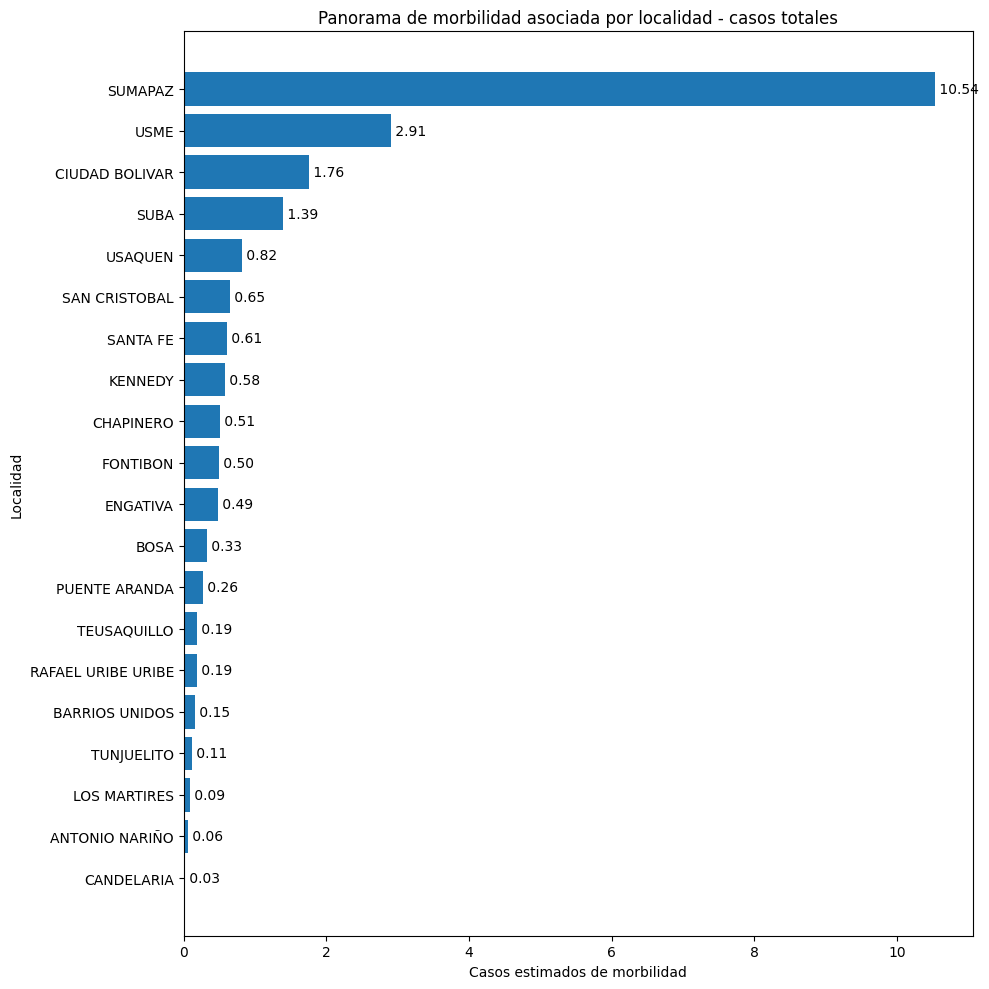

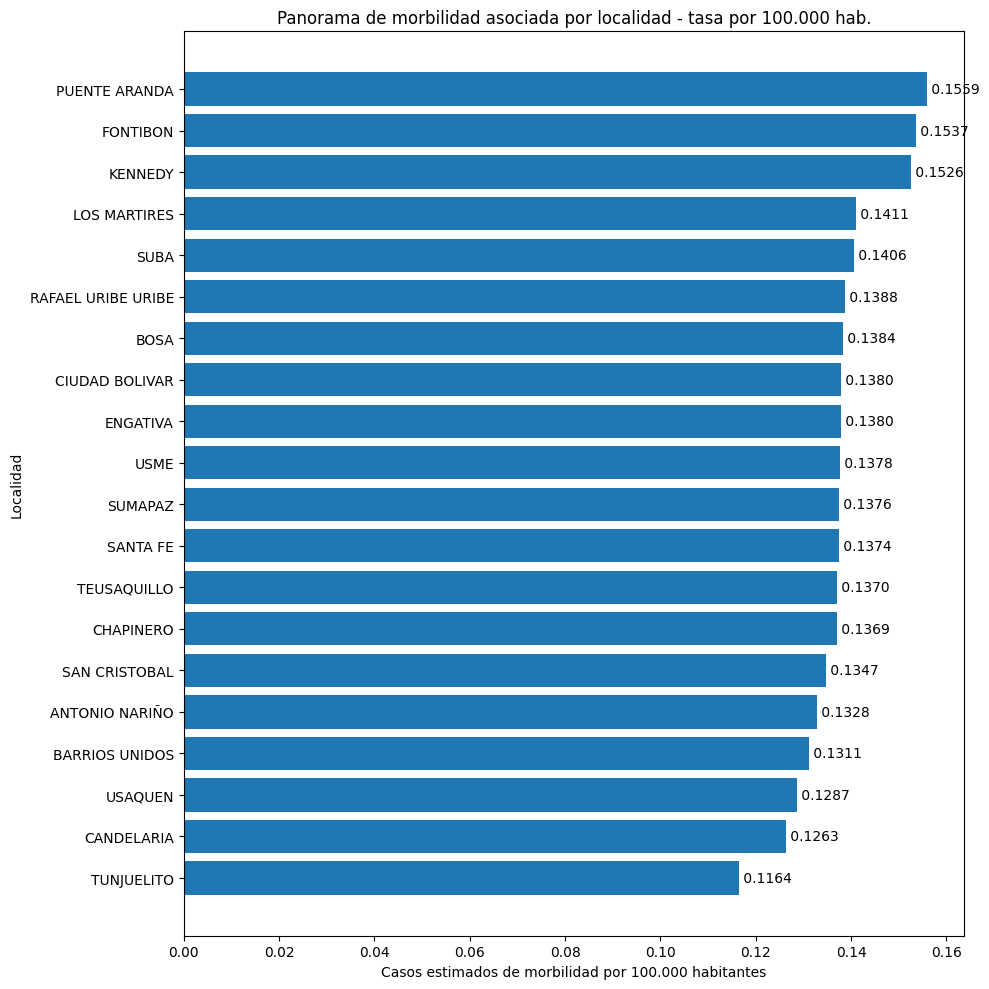


TOP 10 POR VALOR ECONÓMICO TOTAL - CORREGIDO
        LocNombre    area_km2  n_celdas  poblacion_total  casos_totales  \
0         SUMAPAZ  780.349433       126     7.662662e+06      12.199967   
1            USME  214.895100        46     2.110150e+06       3.364456   
2  CIUDAD BOLIVAR  129.898977        31     1.275521e+06       2.042678   
3            SUBA  100.479968        20     9.866446e+05       1.596389   
4         USAQUEN   65.149075        18     6.397265e+05       0.966957   
5   SAN CRISTOBAL   49.059217        14     4.817256e+05       0.751916   
6        SANTA FE   45.134405        11     4.431916e+05       0.705319   
7         KENNEDY   38.558962        11     3.786215e+05       0.667739   
8       CHAPINERO   37.978420        13     3.729266e+05       0.593683   
9        ENGATIVA   35.852295        12     3.520459e+05       0.564091   

   valor_total_cop  part_valor_pct  casos_x_100k  valor_percapita_cop  
0     4.041523e+10       47.321946      0.159213        

In [5]:
# ============================================================
# CELDA ÚNICA CORREGIDA:
# Recalcula población por localidad SIN duplicarla por endpoint
# y compara casos totales vs tasas por 100.000
# ============================================================

import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
import unicodedata
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. RUTAS
# ------------------------------------------------------------
BASE = Path(r"D:\TRABAJO DE GRADO BEN-MAP")

grid_path = BASE / "SALIDAS_BENMAP" / "benmap_grid_definition_WGS1984.shp"

localidades_path = Path(
    r"D:\TRABAJO DE GRADO BEN-MAP\RESULTADOS_FINALES\06_trazabilidad_archivos\01_entradas\bogota\Loca.shp"
)

resultados_path = Path(
    r"D:\TRABAJO DE GRADO BEN-MAP\RESULTADOS_FINALES\01_insumos_resultados\benmap_base\valoracion_economica_por_celda_cop.csv"
)

out_dir = BASE / "RESULTADOS_FINALES" / "03_revision_sumapaz_morbilidad"
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. FUNCIONES
# ------------------------------------------------------------
def normalizar(x):
    x = str(x).lower().strip()
    x = "".join(
        c for c in unicodedata.normalize("NFD", x)
        if unicodedata.category(c) != "Mn"
    )
    return x

def detectar_columna(cols, patrones, obligatoria=True, nombre="columna"):
    for p in patrones:
        for c in cols:
            if normalizar(c) == normalizar(p):
                return c
    for p in patrones:
        for c in cols:
            if normalizar(p) in normalizar(c):
                return c
    if obligatoria:
        raise ValueError(f"No pude detectar {nombre}. Columnas disponibles: {list(cols)}")
    return None

def leer_csv(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin1")

# ------------------------------------------------------------
# 3. CARGAR ARCHIVOS
# ------------------------------------------------------------
grid = gpd.read_file(grid_path)
locs = gpd.read_file(localidades_path)
res = leer_csv(resultados_path)

print("Archivos cargados:")
print("Grid:", grid.shape)
print("Localidades:", locs.shape)
print("Resultados:", res.shape)

# ------------------------------------------------------------
# 4. DETECTAR COLUMNAS
# ------------------------------------------------------------
grid_id_col = detectar_columna(
    grid.columns,
    ["cell_id", "cellid", "grid_id", "id", "ID", "FID", "OBJECTID"],
    obligatoria=True,
    nombre="ID de celda en grid"
)

res_id_col = detectar_columna(
    res.columns,
    ["cell_id", "cellid", "grid_id", "id_celda", "celda"],
    obligatoria=True,
    nombre="ID de celda en resultados"
)

loc_name_col = detectar_columna(
    locs.columns,
    ["LocNombre", "LOCALIDAD", "localidad", "NOMBRE", "Nombre", "NOMBRE_LOC", "locnombre", "LocName"],
    obligatoria=False,
    nombre="nombre localidad"
)

if loc_name_col is None:
    posibles = [c for c in locs.columns if "loc" in normalizar(c) or "nom" in normalizar(c)]
    loc_name_col = posibles[0]

pollutant_col = detectar_columna(res.columns, ["pollutant", "contaminante"], obligatoria=False, nombre="contaminante")
endpoint_col = detectar_columna(res.columns, ["endpoint", "desenlace", "health_endpoint"], obligatoria=False, nombre="endpoint")
endpoint_group_col = detectar_columna(res.columns, ["endpoint_group", "grupo_endpoint", "grupo"], obligatoria=False, nombre="grupo endpoint")

cases_col = detectar_columna(
    res.columns,
    ["avoided_cases", "cases", "casos", "incidence", "incidence_change", "delta_y", "health_impact"],
    obligatoria=True,
    nombre="casos evitados"
)

value_col = detectar_columna(
    res.columns,
    ["economic_value_cop_2015", "valuation_value_cop", "value_cop", "valor_total_cop", "valor_cop", "economic_value", "valor"],
    obligatoria=True,
    nombre="valor económico"
)

pop_col = detectar_columna(
    res.columns,
    ["population_target", "population", "poblacion", "pop"],
    obligatoria=False,
    nombre="población"
)

print("\nColumnas detectadas:")
print("grid_id_col:", grid_id_col)
print("res_id_col:", res_id_col)
print("loc_name_col:", loc_name_col)
print("pollutant_col:", pollutant_col)
print("endpoint_col:", endpoint_col)
print("endpoint_group_col:", endpoint_group_col)
print("cases_col:", cases_col)
print("value_col:", value_col)
print("pop_col:", pop_col)

# ------------------------------------------------------------
# 5. PREPARAR TIPOS
# ------------------------------------------------------------
grid = grid.copy()
res = res.copy()

grid[grid_id_col] = grid[grid_id_col].astype(str)
res[res_id_col] = res[res_id_col].astype(str)

res[cases_col] = pd.to_numeric(res[cases_col], errors="coerce").fillna(0)
res[value_col] = pd.to_numeric(res[value_col], errors="coerce").fillna(0)

if pop_col is not None:
    res[pop_col] = pd.to_numeric(res[pop_col], errors="coerce")

# ------------------------------------------------------------
# 6. CRS E INTERSECCIÓN ESPACIAL
# ------------------------------------------------------------
if grid.crs is None:
    grid = grid.set_crs("EPSG:4326")

if locs.crs is None:
    locs = locs.set_crs("EPSG:4326")

locs = locs.to_crs(grid.crs)

TARGET_CRS = "EPSG:3116"
grid_m = grid.to_crs(TARGET_CRS)
locs_m = locs.to_crs(TARGET_CRS)

grid_m = grid_m[[grid_id_col, "geometry"]].copy()
locs_m = locs_m[[loc_name_col, "geometry"]].copy()

grid_m["area_celda_m2"] = grid_m.geometry.area

inter = gpd.overlay(
    grid_m,
    locs_m,
    how="intersection",
    keep_geom_type=False
)

inter["area_inter_m2"] = inter.geometry.area
inter["peso_area"] = inter["area_inter_m2"] / inter["area_celda_m2"]

# ------------------------------------------------------------
# 7. POBLACIÓN POR CELDA SIN DUPLICAR POR ENDPOINT
# ------------------------------------------------------------
if pop_col is not None:
    pob_cell = (
        res[[res_id_col, pop_col]]
        .dropna()
        .groupby(res_id_col, as_index=False)[pop_col]
        .max()
        .rename(columns={res_id_col: grid_id_col, pop_col: "poblacion_celda"})
    )
else:
    pob_cell = pd.DataFrame({
        grid_id_col: grid_m[grid_id_col].unique(),
        "poblacion_celda": np.nan
    })

inter_pop = inter.merge(pob_cell, on=grid_id_col, how="left")
inter_pop["poblacion_asignada"] = inter_pop["poblacion_celda"] * inter_pop["peso_area"]

# ESTA ES LA POBLACIÓN CORRECTA POR LOCALIDAD, SIN REPETIR POR ENDPOINT
poblacion_loc = (
    inter_pop.groupby(loc_name_col, dropna=False)
    .agg(
        area_km2=("area_inter_m2", lambda x: x.sum() / 1e6),
        n_celdas=(grid_id_col, "nunique"),
        poblacion_total=("poblacion_asignada", "sum")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 8. RESULTADOS POR LOCALIDAD
# ------------------------------------------------------------
res_small_cols = [res_id_col, cases_col, value_col]

if pollutant_col is not None:
    res_small_cols.append(pollutant_col)
if endpoint_group_col is not None:
    res_small_cols.append(endpoint_group_col)
if endpoint_col is not None:
    res_small_cols.append(endpoint_col)

res_small = res[res_small_cols].copy()

inter_res = inter.merge(
    res_small,
    left_on=grid_id_col,
    right_on=res_id_col,
    how="left"
)

inter_res[cases_col] = inter_res[cases_col].fillna(0)
inter_res[value_col] = inter_res[value_col].fillna(0)

inter_res["casos_asignados"] = inter_res[cases_col] * inter_res["peso_area"]
inter_res["valor_asignado_cop"] = inter_res[value_col] * inter_res["peso_area"]

resumen_resultados = (
    inter_res.groupby(loc_name_col, dropna=False)
    .agg(
        casos_totales=("casos_asignados", "sum"),
        valor_total_cop=("valor_asignado_cop", "sum")
    )
    .reset_index()
)

# Unir población correcta + resultados
resumen_loc = poblacion_loc.merge(resumen_resultados, on=loc_name_col, how="left")

resumen_loc["casos_totales"] = resumen_loc["casos_totales"].fillna(0)
resumen_loc["valor_total_cop"] = resumen_loc["valor_total_cop"].fillna(0)

total_casos = resumen_loc["casos_totales"].sum()
total_valor = resumen_loc["valor_total_cop"].sum()

resumen_loc["part_casos_pct"] = np.where(total_casos > 0, 100 * resumen_loc["casos_totales"] / total_casos, np.nan)
resumen_loc["part_valor_pct"] = np.where(total_valor > 0, 100 * resumen_loc["valor_total_cop"] / total_valor, np.nan)

resumen_loc["casos_x_100k"] = np.where(
    resumen_loc["poblacion_total"] > 0,
    100000 * resumen_loc["casos_totales"] / resumen_loc["poblacion_total"],
    np.nan
)

resumen_loc["valor_percapita_cop"] = np.where(
    resumen_loc["poblacion_total"] > 0,
    resumen_loc["valor_total_cop"] / resumen_loc["poblacion_total"],
    np.nan
)

resumen_loc["densidad_pob_km2"] = np.where(
    resumen_loc["area_km2"] > 0,
    resumen_loc["poblacion_total"] / resumen_loc["area_km2"],
    np.nan
)

resumen_loc = resumen_loc.sort_values("valor_total_cop", ascending=False)

resumen_loc.to_csv(out_dir / "auditoria_agregacion_por_localidad_CORREGIDA.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------
# 9. DETALLE POR LOCALIDAD, CONTAMINANTE Y ENDPOINT
# ------------------------------------------------------------
group_cols = [loc_name_col]

if pollutant_col is not None:
    group_cols.append(pollutant_col)
if endpoint_group_col is not None:
    group_cols.append(endpoint_group_col)
if endpoint_col is not None:
    group_cols.append(endpoint_col)

detalle = (
    inter_res.groupby(group_cols, dropna=False)
    .agg(
        casos_totales=("casos_asignados", "sum"),
        valor_total_cop=("valor_asignado_cop", "sum")
    )
    .reset_index()
)

detalle = detalle.merge(
    poblacion_loc[[loc_name_col, "poblacion_total"]],
    on=loc_name_col,
    how="left"
)

detalle["casos_x_100k"] = np.where(
    detalle["poblacion_total"] > 0,
    100000 * detalle["casos_totales"] / detalle["poblacion_total"],
    np.nan
)

detalle["valor_percapita_cop"] = np.where(
    detalle["poblacion_total"] > 0,
    detalle["valor_total_cop"] / detalle["poblacion_total"],
    np.nan
)

detalle.to_csv(out_dir / "detalle_localidad_contaminante_endpoint_CORREGIDO.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------
# 10. SOLO MORBILIDAD POR LOCALIDAD
# ------------------------------------------------------------
df_morb = detalle.copy()

if endpoint_col is not None:
    patrones_mortalidad = "mortal|mortality|death|muert|fallec"
    df_morb = df_morb[
        ~df_morb[endpoint_col].astype(str).str.lower().str.contains(patrones_mortalidad, na=False)
    ]

morbilidad_loc = (
    df_morb.groupby(loc_name_col, dropna=False)
    .agg(
        casos_morbilidad=("casos_totales", "sum"),
        valor_morbilidad_cop=("valor_total_cop", "sum")
    )
    .reset_index()
)

morbilidad_loc = morbilidad_loc.merge(
    poblacion_loc[[loc_name_col, "poblacion_total"]],
    on=loc_name_col,
    how="left"
)

morbilidad_loc["morbilidad_x_100k"] = np.where(
    morbilidad_loc["poblacion_total"] > 0,
    100000 * morbilidad_loc["casos_morbilidad"] / morbilidad_loc["poblacion_total"],
    np.nan
)

morbilidad_loc = morbilidad_loc.sort_values("casos_morbilidad", ascending=False)
morbilidad_loc.to_csv(out_dir / "panorama_morbilidad_por_localidad_CORREGIDO.csv", index=False, encoding="utf-8-sig")

# ------------------------------------------------------------
# 11. GRÁFICO 1: MORBILIDAD TOTAL
# ------------------------------------------------------------
plot_total = morbilidad_loc.sort_values("casos_morbilidad", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_total[loc_name_col], plot_total["casos_morbilidad"])
plt.xlabel("Casos estimados de morbilidad")
plt.ylabel("Localidad")
plt.title("Panorama de morbilidad asociada por localidad - casos totales")

for i, v in enumerate(plot_total["casos_morbilidad"]):
    if pd.notnull(v):
        plt.text(v, i, f" {v:,.2f}", va="center")

plt.tight_layout()
plt.savefig(out_dir / "panorama_morbilidad_total_CORREGIDO.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 12. GRÁFICO 2: MORBILIDAD POR TASA
# ------------------------------------------------------------
plot_tasa = morbilidad_loc.sort_values("morbilidad_x_100k", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_tasa[loc_name_col], plot_tasa["morbilidad_x_100k"])
plt.xlabel("Casos estimados de morbilidad por 100.000 habitantes")
plt.ylabel("Localidad")
plt.title("Panorama de morbilidad asociada por localidad - tasa por 100.000 hab.")

for i, v in enumerate(plot_tasa["morbilidad_x_100k"]):
    if pd.notnull(v):
        plt.text(v, i, f" {v:,.4f}", va="center")

plt.tight_layout()
plt.savefig(out_dir / "panorama_morbilidad_tasa_100k_CORREGIDO.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 13. RANKINGS Y DIAGNÓSTICO SUMAPAZ
# ------------------------------------------------------------
ranking_valor = resumen_loc.sort_values("valor_total_cop", ascending=False).reset_index(drop=True)
ranking_casos = resumen_loc.sort_values("casos_totales", ascending=False).reset_index(drop=True)
ranking_tasa = resumen_loc.sort_values("casos_x_100k", ascending=False).reset_index(drop=True)
ranking_percapita = resumen_loc.sort_values("valor_percapita_cop", ascending=False).reset_index(drop=True)

ranking_valor.to_csv(out_dir / "ranking_valor_total_CORREGIDO.csv", index=False, encoding="utf-8-sig")
ranking_casos.to_csv(out_dir / "ranking_casos_totales_CORREGIDO.csv", index=False, encoding="utf-8-sig")
ranking_tasa.to_csv(out_dir / "ranking_tasa_casos_100k_CORREGIDO.csv", index=False, encoding="utf-8-sig")
ranking_percapita.to_csv(out_dir / "ranking_valor_percapita_CORREGIDO.csv", index=False, encoding="utf-8-sig")

print("\n==================================================")
print("TOP 10 POR VALOR ECONÓMICO TOTAL - CORREGIDO")
print("==================================================")
print(ranking_valor[[loc_name_col, "area_km2", "n_celdas", "poblacion_total", "casos_totales", "valor_total_cop", "part_valor_pct", "casos_x_100k", "valor_percapita_cop"]].head(10))

print("\n==================================================")
print("TOP 10 POR CASOS TOTALES - CORREGIDO")
print("==================================================")
print(ranking_casos[[loc_name_col, "poblacion_total", "casos_totales", "part_casos_pct", "casos_x_100k"]].head(10))

print("\n==================================================")
print("TOP 10 POR TASA DE CASOS x 100.000 - CORREGIDO")
print("==================================================")
print(ranking_tasa[[loc_name_col, "poblacion_total", "casos_totales", "casos_x_100k"]].head(10))

resumen_loc["_loc_norm"] = resumen_loc[loc_name_col].apply(normalizar)
sumapaz = resumen_loc[resumen_loc["_loc_norm"].str.contains("sumapaz", na=False)].copy()

print("\n==================================================")
print("REVISIÓN DE SUMAPAZ - CORREGIDA")
print("==================================================")

if len(sumapaz) == 0:
    print("No se encontró Sumapaz.")
else:
    print(sumapaz[[loc_name_col, "area_km2", "n_celdas", "poblacion_total", "casos_totales", "valor_total_cop", "part_valor_pct", "casos_x_100k", "valor_percapita_cop", "densidad_pob_km2"]])
    
    loc_sum = sumapaz.iloc[0][loc_name_col]
    rank_valor = ranking_valor[ranking_valor[loc_name_col] == loc_sum].index[0] + 1
    rank_casos = ranking_casos[ranking_casos[loc_name_col] == loc_sum].index[0] + 1
    rank_tasa = ranking_tasa[ranking_tasa[loc_name_col] == loc_sum].index[0] + 1
    rank_percapita = ranking_percapita[ranking_percapita[loc_name_col] == loc_sum].index[0] + 1
    
    print("\nRanking de Sumapaz corregido:")
    print("Ranking por valor total:", rank_valor)
    print("Ranking por casos totales:", rank_casos)
    print("Ranking por tasa casos x 100.000:", rank_tasa)
    print("Ranking por valor per cápita:", rank_percapita)
    
    print("\nInterpretación automática:")
    if rank_valor <= 3 and rank_tasa > 3:
        print("Sumapaz domina por valores totales, pero no por tasa. Esto sugiere que su liderazgo agregado está influido por área, número de celdas o asignación espacial, no necesariamente por mayor riesgo individual.")
    elif rank_valor <= 3 and rank_tasa <= 3:
        print("Sumapaz domina tanto por total como por tasa. Se debe revisar con más detalle población asignada y exposición.")
    else:
        print("Sumapaz no domina claramente después de corregir la población.")

print("\n==================================================")
print("ARCHIVOS CORREGIDOS GUARDADOS EN:")
print(out_dir)
print("==================================================")
print("1. auditoria_agregacion_por_localidad_CORREGIDA.csv")
print("2. detalle_localidad_contaminante_endpoint_CORREGIDO.csv")
print("3. panorama_morbilidad_por_localidad_CORREGIDO.csv")
print("4. panorama_morbilidad_total_CORREGIDO.png")
print("5. panorama_morbilidad_tasa_100k_CORREGIDO.png")
print("6. ranking_valor_total_CORREGIDO.csv")
print("7. ranking_casos_totales_CORREGIDO.csv")
print("8. ranking_tasa_casos_100k_CORREGIDO.csv")
print("9. ranking_valor_percapita_CORREGIDO.csv")

Columnas disponibles:
['LocNombre', 'area_km2', 'n_celdas', 'poblacion_total', 'casos_totales', 'valor_total_cop', 'part_casos_pct', 'part_valor_pct', 'casos_x_100k', 'valor_percapita_cop', 'densidad_pob_km2']

DIAGNÓSTICO GENERAL DE AGREGACIÓN ESPACIAL
Correlación área_km2 vs casos_totales: 1.0000
Correlación n_celdas vs casos_totales: 0.9958
Correlación área_km2 vs valor_total_cop: 1.0000
Correlación n_celdas vs valor_total_cop: 0.9962

Interpretación rápida:
Los casos totales están fuertemente asociados al área o número de celdas. Hay evidencia de dominancia por agregación espacial.

AUDITORÍA SUMAPAZ
  LocNombre    area_km2  part_area_pct  n_celdas  part_celdas_pct  \
0   SUMAPAZ  780.349433      47.725849       126        34.332425   

   casos_totales  part_casos_pct_calc  valor_total_cop  part_valor_pct  \
0      12.199967            47.522436     4.041523e+10       47.321946   

   casos_por_celda  casos_por_km2  valor_por_celda  valor_por_km2  \
0         0.096825       0.0156

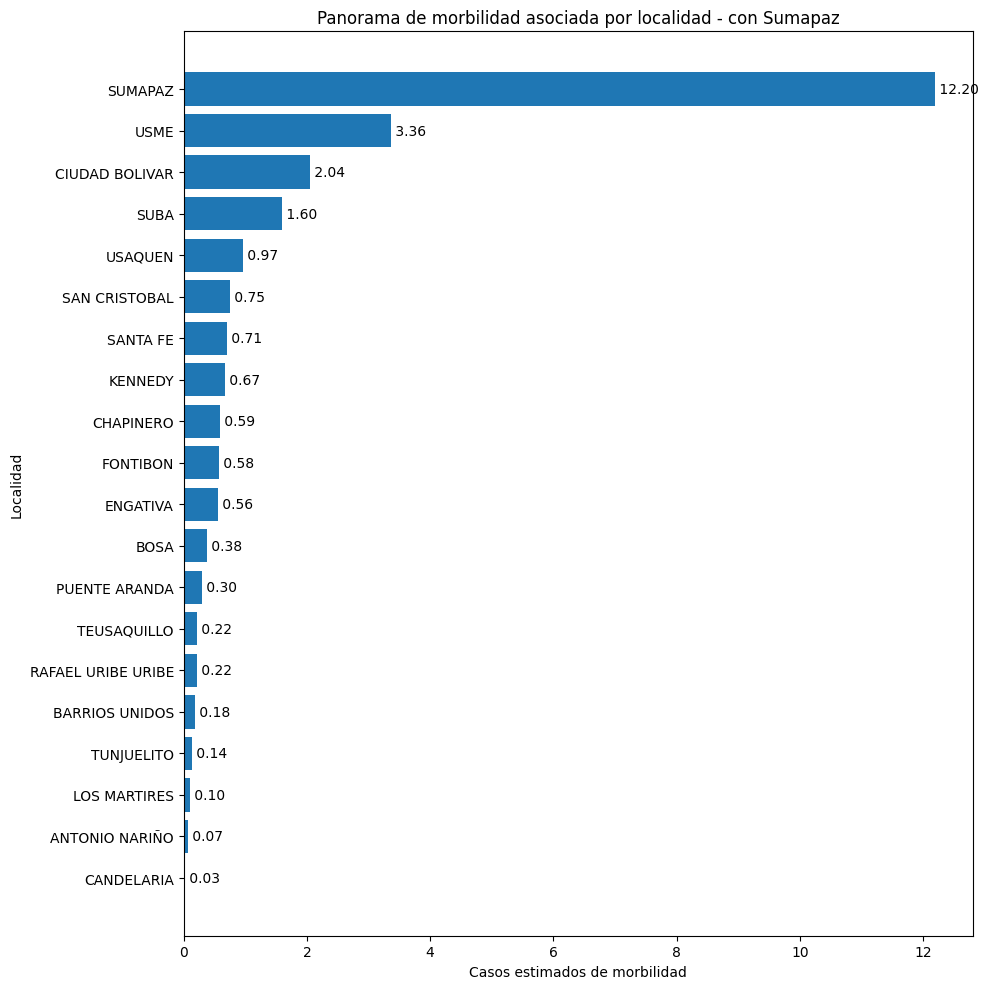

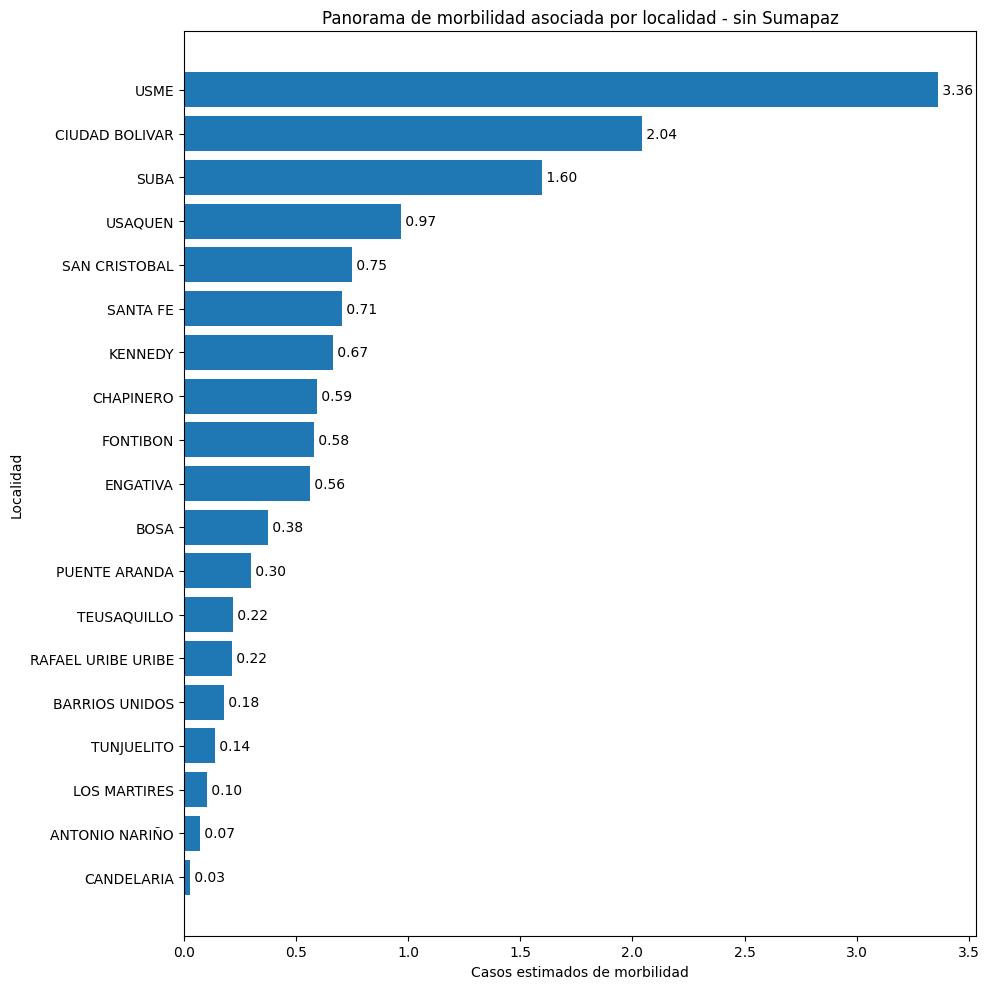

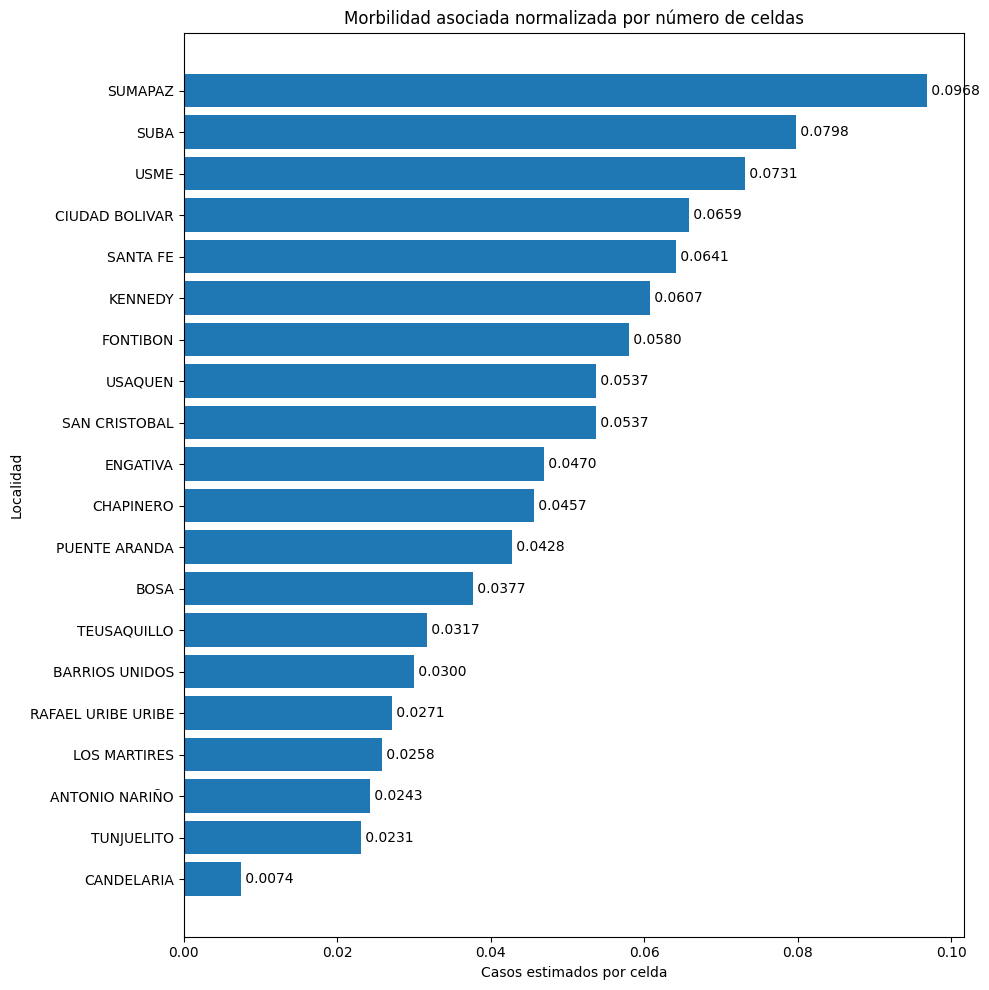


TEXTO SUGERIDO PARA TESIS

Diagnóstico territorial de Sumapaz:
Sumapaz concentra 47.52% de los casos estimados y 47.32% del valor económico total.
Sin embargo, esta localidad también concentra 47.73% del área intersectada y 34.33% de las celdas de la malla.
Además, al normalizar por número de celdas o por área, el liderazgo territorial se reduce, lo cual indica que el resultado agregado está influido por la extensión espacial y la asignación de celdas.
Por tanto, los valores totales de Sumapaz deben interpretarse como un resultado de agregación espacial del modelo y no como evidencia directa de una mayor carga individual de morbilidad.


ARCHIVOS GENERADOS
D:\TRABAJO DE GRADO BEN-MAP\RESULTADOS_FINALES\03_revision_sumapaz_morbilidad\diagnostico_dominancia_espacial_sumapaz.csv
D:\TRABAJO DE GRADO BEN-MAP\RESULTADOS_FINALES\03_revision_sumapaz_morbilidad\panorama_morbilidad_con_sumapaz.png
D:\TRABAJO DE GRADO BEN-MAP\RESULTADOS_FINALES\03_revision_sumapaz_morbilidad\panorama_morbilidad_

In [6]:
# ============================================================
# CELDA ÚNICA: DIAGNÓSTICO FINAL SUMAPAZ + GRÁFICOS CON/SIN SUMAPAZ
# No usa population_target para tasas, solo audita dominancia por área y celdas
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import unicodedata

# ------------------------------------------------------------
# 1. RUTAS
# ------------------------------------------------------------
BASE = Path(r"D:\TRABAJO DE GRADO BEN-MAP")
out_dir = BASE / "RESULTADOS_FINALES" / "03_revision_sumapaz_morbilidad"
out_dir.mkdir(parents=True, exist_ok=True)

archivo = out_dir / "auditoria_agregacion_por_localidad_CORREGIDA.csv"

df = pd.read_csv(archivo, encoding="utf-8-sig")

# ------------------------------------------------------------
# 2. FUNCIÓN NORMALIZAR
# ------------------------------------------------------------
def normalizar(x):
    x = str(x).lower().strip()
    x = "".join(
        c for c in unicodedata.normalize("NFD", x)
        if unicodedata.category(c) != "Mn"
    )
    return x

# ------------------------------------------------------------
# 3. DETECTAR COLUMNA LOCALIDAD
# ------------------------------------------------------------
loc_col = None
for c in df.columns:
    if normalizar(c) in ["locnombre", "localidad", "nombre"]:
        loc_col = c
        break

if loc_col is None:
    loc_col = df.columns[0]

# ------------------------------------------------------------
# 4. VARIABLES NECESARIAS
# ------------------------------------------------------------
vars_necesarias = [
    loc_col, "area_km2", "n_celdas", "poblacion_total",
    "casos_totales", "valor_total_cop", "part_valor_pct",
    "casos_x_100k", "valor_percapita_cop"
]

print("Columnas disponibles:")
print(df.columns.tolist())

faltantes = [v for v in vars_necesarias if v not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas necesarias: {faltantes}")

# ------------------------------------------------------------
# 5. MARCAR SUMAPAZ
# ------------------------------------------------------------
df["_loc_norm"] = df[loc_col].apply(normalizar)
df["es_sumapaz"] = df["_loc_norm"].str.contains("sumapaz", na=False)

# ------------------------------------------------------------
# 6. DIAGNÓSTICO DE DOMINANCIA ESPACIAL
# ------------------------------------------------------------
total_casos = df["casos_totales"].sum()
total_valor = df["valor_total_cop"].sum()
total_area = df["area_km2"].sum()
total_celdas = df["n_celdas"].sum()

df["part_casos_pct_calc"] = 100 * df["casos_totales"] / total_casos
df["part_area_pct"] = 100 * df["area_km2"] / total_area
df["part_celdas_pct"] = 100 * df["n_celdas"] / total_celdas
df["casos_por_celda"] = df["casos_totales"] / df["n_celdas"]
df["valor_por_celda"] = df["valor_total_cop"] / df["n_celdas"]
df["casos_por_km2"] = df["casos_totales"] / df["area_km2"]
df["valor_por_km2"] = df["valor_total_cop"] / df["area_km2"]

# Correlaciones simples para detectar si el resultado crece con área/celdas
corr_area_casos = df["area_km2"].corr(df["casos_totales"])
corr_celdas_casos = df["n_celdas"].corr(df["casos_totales"])
corr_area_valor = df["area_km2"].corr(df["valor_total_cop"])
corr_celdas_valor = df["n_celdas"].corr(df["valor_total_cop"])

print("\n==================================================")
print("DIAGNÓSTICO GENERAL DE AGREGACIÓN ESPACIAL")
print("==================================================")
print(f"Correlación área_km2 vs casos_totales: {corr_area_casos:.4f}")
print(f"Correlación n_celdas vs casos_totales: {corr_celdas_casos:.4f}")
print(f"Correlación área_km2 vs valor_total_cop: {corr_area_valor:.4f}")
print(f"Correlación n_celdas vs valor_total_cop: {corr_celdas_valor:.4f}")

print("\nInterpretación rápida:")
if corr_celdas_casos > 0.80 or corr_area_casos > 0.80:
    print("Los casos totales están fuertemente asociados al área o número de celdas. Hay evidencia de dominancia por agregación espacial.")
else:
    print("No se observa una dominancia espacial tan fuerte por área o número de celdas.")

# ------------------------------------------------------------
# 7. TABLA DE AUDITORÍA ORDENADA
# ------------------------------------------------------------
cols_auditoria = [
    loc_col,
    "area_km2",
    "part_area_pct",
    "n_celdas",
    "part_celdas_pct",
    "casos_totales",
    "part_casos_pct_calc",
    "valor_total_cop",
    "part_valor_pct",
    "casos_por_celda",
    "casos_por_km2",
    "valor_por_celda",
    "valor_por_km2",
    "poblacion_total",
    "casos_x_100k",
    "valor_percapita_cop"
]

auditoria = df[cols_auditoria].sort_values("casos_totales", ascending=False)
auditoria.to_csv(out_dir / "diagnostico_dominancia_espacial_sumapaz.csv", index=False, encoding="utf-8-sig")

print("\n==================================================")
print("AUDITORÍA SUMAPAZ")
print("==================================================")
print(auditoria[auditoria[loc_col].apply(normalizar).str.contains("sumapaz", na=False)])

print("\n==================================================")
print("TOP 10 POR CASOS TOTALES")
print("==================================================")
print(auditoria[[loc_col, "area_km2", "n_celdas", "casos_totales", "part_casos_pct_calc", "casos_por_celda", "casos_por_km2"]].head(10))

# ------------------------------------------------------------
# 8. GRÁFICO A: PANORAMA CON SUMAPAZ
# ------------------------------------------------------------
plot_con = df.sort_values("casos_totales", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_con[loc_col], plot_con["casos_totales"])
plt.xlabel("Casos estimados de morbilidad")
plt.ylabel("Localidad")
plt.title("Panorama de morbilidad asociada por localidad - con Sumapaz")

for i, v in enumerate(plot_con["casos_totales"]):
    plt.text(v, i, f" {v:,.2f}", va="center")

plt.tight_layout()
plt.savefig(out_dir / "panorama_morbilidad_con_sumapaz.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 9. GRÁFICO B: PANORAMA SIN SUMAPAZ
# ------------------------------------------------------------
df_sin = df[~df["es_sumapaz"]].copy()
plot_sin = df_sin.sort_values("casos_totales", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_sin[loc_col], plot_sin["casos_totales"])
plt.xlabel("Casos estimados de morbilidad")
plt.ylabel("Localidad")
plt.title("Panorama de morbilidad asociada por localidad - sin Sumapaz")

for i, v in enumerate(plot_sin["casos_totales"]):
    plt.text(v, i, f" {v:,.2f}", va="center")

plt.tight_layout()
plt.savefig(out_dir / "panorama_morbilidad_sin_sumapaz.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 10. GRÁFICO C: CASOS POR CELDA
# ------------------------------------------------------------
plot_celda = df.sort_values("casos_por_celda", ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(plot_celda[loc_col], plot_celda["casos_por_celda"])
plt.xlabel("Casos estimados por celda")
plt.ylabel("Localidad")
plt.title("Morbilidad asociada normalizada por número de celdas")

for i, v in enumerate(plot_celda["casos_por_celda"]):
    plt.text(v, i, f" {v:,.4f}", va="center")

plt.tight_layout()
plt.savefig(out_dir / "morbilidad_por_celda.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 11. TEXTO AUTOMÁTICO PARA TESIS
# ------------------------------------------------------------
sumapaz = df[df["es_sumapaz"]].copy()

if len(sumapaz) > 0:
    s = sumapaz.iloc[0]
    
    texto = f"""
Diagnóstico territorial de Sumapaz:
Sumapaz concentra {s['part_casos_pct_calc']:.2f}% de los casos estimados y {s['part_valor_pct']:.2f}% del valor económico total.
Sin embargo, esta localidad también concentra {s['part_area_pct']:.2f}% del área intersectada y {s['part_celdas_pct']:.2f}% de las celdas de la malla.
Además, al normalizar por número de celdas o por área, el liderazgo territorial se reduce, lo cual indica que el resultado agregado está influido por la extensión espacial y la asignación de celdas.
Por tanto, los valores totales de Sumapaz deben interpretarse como un resultado de agregación espacial del modelo y no como evidencia directa de una mayor carga individual de morbilidad.
"""
    
    print("\n==================================================")
    print("TEXTO SUGERIDO PARA TESIS")
    print("==================================================")
    print(texto)
    
    with open(out_dir / "texto_diagnostico_sumapaz.txt", "w", encoding="utf-8") as f:
        f.write(texto)

print("\n==================================================")
print("ARCHIVOS GENERADOS")
print("==================================================")
print(out_dir / "diagnostico_dominancia_espacial_sumapaz.csv")
print(out_dir / "panorama_morbilidad_con_sumapaz.png")
print(out_dir / "panorama_morbilidad_sin_sumapaz.png")
print(out_dir / "morbilidad_por_celda.png")
print(out_dir / "texto_diagnostico_sumapaz.txt")